In [1]:
import numpy as np
import scipy.stats
import scipy.special
import matplotlib.pyplot as plt
import random
import yaml
SEED = 12345
random.seed(SEED)
np.random.seed(SEED)

# 1 Parameter inference for the linear Gaussian model
Consider the following scalar linear Gaussian model

$$X_n = \rho X_{n-1} + \tau V_n $$

$$Y_n = X_n + \sigma W_n$$

where $W_n, V_n \overset{i.i.d}{\sim} N(0, 1), X_0 ∼ N(0, 1)$. We first run the model to synthesise a data set $y_{0:T}$ for $T = 100, \rho = 0.8, \tau = 1, \sigma = 0.5$. We also store the real state trajectory, $x_{0:T}$. Let $\theta = (\rho, \tau)$ and assume $\sigma$ is known. Let also $\rho \in [-1,1]$ and
$\tau \in (0, 2]$. We wish to perform Bayesian inference using MCMC with the priors $\rho \sim U[-1,1]$ and $\tau \sim N_{(0,2]}(1,1)$, where the latter denotes a truncated normal distribution in $(0, 2]$.

In [2]:
# Import trajectory 
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/lgssm/data/"
experiment_ID = 1
trajectory_path = results_path + f"trajectory{experiment_ID}.npz"
trajectory_config_path = results_path + f"trajectory{experiment_ID}.yaml"

trajectory = np.load(trajectory_path)
T = 30 # Length of time series to use
x = trajectory["x"][:T]
z = trajectory["z"][:T]

with open(trajectory_config_path, "r") as f:
    trajectory_config = yaml.safe_load(f)
rho_true = trajectory_config["rho_true"]
sigma_true = trajectory_config["sigma_true"]
tau_true = trajectory_config["tau_true"]
trajectory_config

{'length': 5000, 'rho_true': 0.8, 'sigma_true': 0.5, 'tau_true': 1.0}

In [3]:
def log_likelihood(x, rho, tau, sigma_true):
    T = len(x) - 1
    sigma_true2 = sigma_true ** 2
    log_lik = 0.0
    for k in range(T + 1):
        if k == 0:
            mu_pred = 0.0
            s2_pred = 1.0
        else:
            mu_pred = rho * mu_filt
            s2_pred = rho ** 2 * s2_filt + tau ** 2
        s2_innov = s2_pred + sigma_true2
        innov = x[k] - mu_pred
        log_lik += scipy.stats.norm.logpdf(innov, loc=0.0, scale=np.sqrt(s2_innov))
        K = s2_pred / s2_innov
        mu_filt = mu_pred + K * innov
        s2_filt = s2_pred - K * s2_pred
    return log_lik

def log_prior(rho, tau, rho_lower, rho_upper,
              tau_loc, tau_scale, tau_lower, tau_upper):
    if not (rho_lower < rho < rho_upper):
        return -np.inf
    if not (tau_lower < tau < tau_upper):
        return -np.inf
    rho_logpdf = scipy.stats.uniform.logpdf(rho, loc=rho_lower, scale=rho_upper-rho_lower)
    tau_logpdf = scipy.stats.truncnorm.logpdf(tau,
                 a=(tau_lower - tau_loc) / tau_scale,
                 b=(tau_upper - tau_loc) / tau_scale,
                 loc=tau_loc, scale=tau_scale)
    return rho_logpdf + tau_logpdf


def log_unnormalized_posterior(rho, tau, x, sigma_true,
                                rho_lower, rho_upper,
                                tau_loc, tau_scale, tau_lower, tau_upper):
    return log_likelihood(x, rho, tau, sigma_true) + log_prior(
        rho, tau,
        rho_lower, rho_upper,
        tau_loc, tau_scale, tau_lower, tau_upper
    )


def proposal_rv(rho_old, tau_old, proposal_sigmas):
    proposal_sigmas = np.array(proposal_sigmas)
    return np.array([rho_old, tau_old]) + proposal_sigmas * np.random.randn(2)


def metropolis_hastings(rho_0, tau_0, x, sigma_true, proposal_sigmas, num_iterations,
                        rho_lower, rho_upper,
                        tau_loc, tau_scale, tau_lower, tau_upper):
    samples = np.zeros((num_iterations, 2))
    rho_prev = rho_0
    tau_prev = tau_0
    log_post_prev = log_unnormalized_posterior(
        rho_prev, tau_prev, x, sigma_true,
        rho_lower, rho_upper,
        tau_loc, tau_scale, tau_lower, tau_upper
    )
    rejections = 0
    for i in range(num_iterations):
        if i % (num_iterations // 10) == 0:
            print(f"{100 * i / num_iterations:.0f}% done")
        proposed = proposal_rv(rho_prev, tau_prev, proposal_sigmas)
        rho_prop, tau_prop = proposed[0], proposed[1]
        log_post_prop = log_unnormalized_posterior(
            rho_prop, tau_prop, x, sigma_true,
            rho_lower, rho_upper,
            tau_loc, tau_scale, tau_lower, tau_upper
        )
        log_alpha = log_post_prop - log_post_prev
        if np.log(np.random.uniform()) < log_alpha:
            rho_prev = rho_prop
            tau_prev = tau_prop
            log_post_prev = log_post_prop
        else:
            rejections += 1
        samples[i] = [rho_prev, tau_prev]
    return samples, rejections / num_iterations

In [4]:
# Prior hyperparameters
rho_lower, rho_upper = -1.0, 1.0
tau_loc, tau_scale, tau_lower, tau_upper = 1.0, 1.0, 0.0, 2.0

# Run
rho_0, tau_0 = 0, 0.5
proposal_sigmas = (0.1, 0.1)
num_iterations = 20000

samples, rejection_rate = metropolis_hastings(
    rho_0, tau_0, x, sigma_true, proposal_sigmas, num_iterations,
    rho_lower, rho_upper,
    tau_loc, tau_scale, tau_lower, tau_upper)

0% done
10% done
20% done
30% done
40% done
50% done
60% done
70% done
80% done
90% done


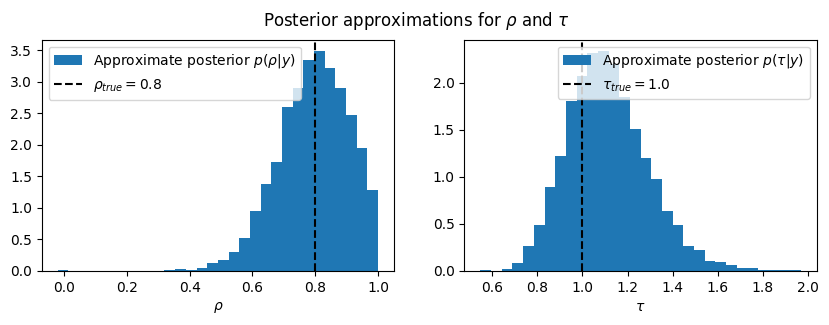

In [5]:
rho_samples = [sample[0] for sample in samples]
tau_samples = [sample[1] for sample in samples]

fig, ax = plt.subplots(figsize=(10,3), ncols=2)

bins=30
ax[0].hist(rho_samples, bins=bins, density=True, label=r"Approximate posterior $p(\rho | y)$")
ax[0].axvline(rho_true, linestyle="--", label=r"$\rho_{true} = $" + str(rho_true), color="k")
ax[0].set_xlabel(r"$\rho$")
ax[0].legend()

ax[1].hist(tau_samples, bins=bins, density=True, label=r"Approximate posterior $p(\tau | y)$")
ax[1].axvline(tau_true, linestyle="--", label=r"$\tau_{true} = $" + str(tau_true), color="k")
ax[1].set_xlabel(r"$\tau$")
ax[1].legend()

plt.suptitle(r"Posterior approximations for $\rho$ and $\tau$")

plt.show()